### For this assessment you have been provided a single dataset, `gourds.csv`. This dataset contains the results of the Great Pumpkin Commonwealth Weighoff for the years 2013 through 2021. The columns of this dataframe are contained in the data dictionary.md file. 

### Your notebook should be able to be run error-free from top to bottom, including the `read_csv` calls.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Instructions


#### 0. Make a markdown cell in your notebook and type the following: "I, <Your Name>, did not use ChatGPT or any other AI/LLM to assist me on this assessment"


In [2]:
name = 'Michelle Ruppert'

print(f'I, {name}, did not use ChatGPT or any other AI/LLM to assist me on this assessment')

I, Michelle Ruppert, did not use ChatGPT or any other AI/LLM to assist me on this assessment


#### 1. Create a Jupyter notebook and name it <firstname_gourds>. For example, John Smith's notebook would be named `john_gourds.ipynb`


#### 2. Read in the gourds data into a DataFrame named `gourds` and look at the top 5 rows.


In [3]:
gourds = pd.read_csv('./data/gourds.csv')
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
0,2013,F,154.5 lb,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5
1,2013,F,146.5 lb,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5
2,2013,F,145.0 lb,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0
3,2013,F,140.8 lb,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8
4,2013,F,139.0 lb,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0


#### 3. Which country shows up the most frequently in the dataset? Create a visualization (your choice) to show the frequency of appearances for the top 5 countries in terms of number of appearances.


In [4]:
# Countries listed with most gourds
gourds['country'].value_counts()

country
United States      17070
Canada              4522
Germany             2175
Italy                846
Austria              602
France               405
Belgium              360
Japan                358
United Kingdom       292
The Netherlands      248
Finland              244
Spain                229
Slovenia             167
Switzerland          166
Portugal             149
New Zealand           77
Poland                73
Ireland               21
Australia              5
Unknown country        1
Luxembourg             1
Name: count, dtype: int64

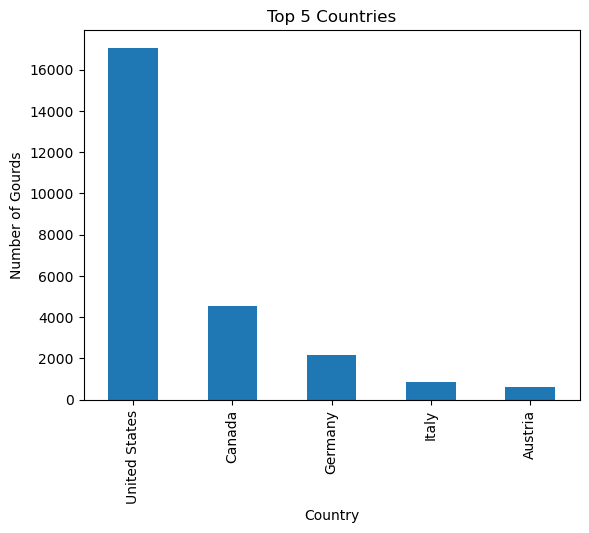

In [5]:
# Bar chart of top 5 countries with most gourds
gourds['country'].value_counts().head(5).plot(kind='bar')

plt.title('Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Gourds')
plt.show()

##### The United States shows up the most frequently with over 17,000 gourd entries.

#### 4. The `weight` column currently contains a unit ("in" for Long Gourds and "lb" for every other type). Remove the unit from this so that you just have the numeric value and save the result back to the `weight` column. After doing this, sort the values on the weight column. You should find that the heaviest gourd in the dataset weighs 2702.9 lb. If you cannot find a solution for this question, you can use the `weight_bk` to answer the questions below that rely on it.


In [6]:
# Remove units of measurement and convert to a float
gourds['weight'] = gourds['weight'].str.replace('lb', '').str.replace('in', '').astype(float)

# Sort values to verify 
gourds.sort_values('weight', ascending=False).head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
25730,2021,P,2702.9,1.0,"Cutrupi, Stefano",Radda in Chianti,Tuscany,Italy,Campionato dello Zuccone,1885.5 Werner,Self,514.0,2553.0,NaN,2702.9
9964,2016,P,2624.6,1.0,"Willemijns, Mathias",Deurle,East Flanders,Belgium,Europameisterschaft im Kurbiswiegen,2145 McMullen,1872 Willemijns,496.0,2175.0,NaN,2624.6
22871,2020,P,2593.7,1.0,"Paton, Ian & Stuart",Everton nr. Lymington,England,United Kingdom,Royal Victoria Country Park,"1875 MENDI ""B""",2005 HAIST,502.0,2431.0,NaN,2593.7
22872,2020,P,2551.9,2.0,"Mendi, Ruben",VALTIERRA,Navarre,Spain,Concurso Calabazas Gigantes de Valtierra,2183.7 Mendi 2019,self,485.0,2255.0,NaN,2551.9
16260,2018,P,2528.0,1.0,"Geddes, Steve",Boscawen,New Hampshire,United States,Deerfield Fair,1911 Urena,1803 Gadberry,490.0,2307.0,NaN,2528.0


#### 5. Create a line plot showing the trend in the **heaviest** gourd by year. What do you notice?


In [7]:
# Group to find max weight

big_gourds = gourds.groupby('year')['weight'].max()

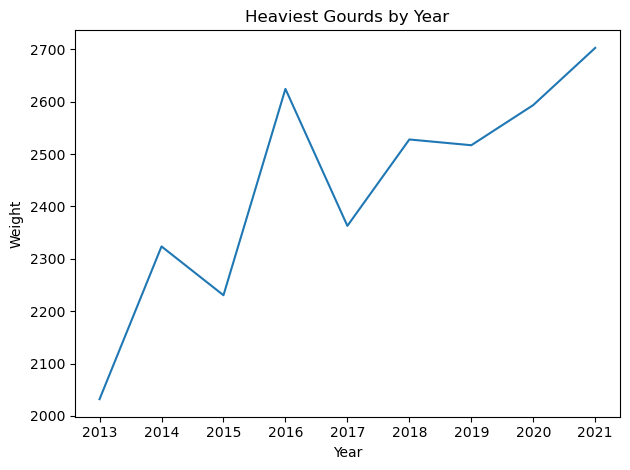

In [8]:
# Line plot to show heaviest gourds

big_gourds.plot(kind='line')

plt.title('Heaviest Gourds by Year')
plt.xlabel('Year')
plt.ylabel('Weight')
plt.tight_layout()
plt.show()

#### 6. Read the `type_name.csv` dataset into a new DataFrame named `type_name`. Merge this with `gourds` to add on `type_name` column. Which type of gourd is heaviest on average? Create a visualization showing the distribution of gourd weights by type.

In [9]:
type_name = pd.read_csv('./data/type_name.csv')
type_name.head()

,type_id,type_name
0,F,Field Pumpkin
1,P,Giant Pumpkin
2,S,Giant Squash
3,W,Giant Watermelon
4,T,Tomato


In [10]:
# Merge dataframes together on type_id
gourds = pd.merge(gourds, type_name, on='type_id')
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin


In [11]:
# Group to find which type is heaviest

gourds.groupby('type_name')['weight'].mean().sort_values(ascending=False)

type_name
Giant Pumpkin       776.033885
Giant Squash        527.298348
Giant Watermelon    127.149110
Long Gourd           94.567945
Field Pumpkin        79.456309
Tomato                3.176921
Name: weight, dtype: float64

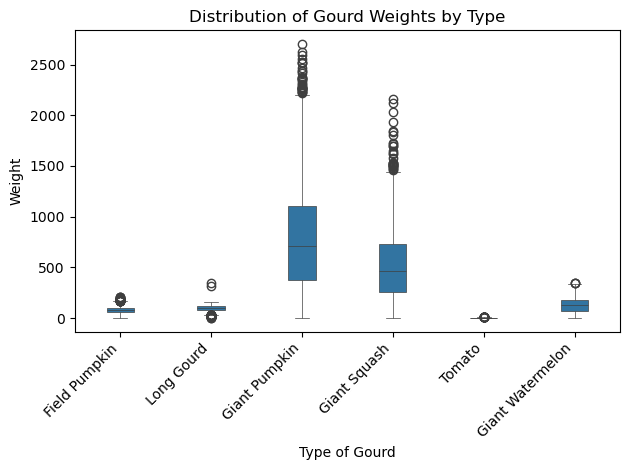

In [12]:
# Visual of Gourds by type
import seaborn as sns

sns.boxplot(data=gourds, x='type_name', y='weight', width=.3, linewidth=.50)

plt.title('Distribution of Gourd Weights by Type')
plt.xlabel('Type of Gourd')
plt.ylabel('Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 7. Create a new column `weight_error` that contains the amount by which the estimated weight exceeded the actual weight. What is the worst overestimate of a gourd weight? What percentage of gourd weights are overestimated?

In [13]:
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin


In [14]:
# Create new column showing difference of weight and estimated weight

gourds['weight_error'] = gourds['est_weight'] - gourds['weight']

gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin,-25.5
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin,4.5
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin,-30.0
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin,10.2
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin,-139.0


In [15]:
# View max overestimate

gourds['weight_error'].max()

10717.0

In [16]:
# Percentage of overestimated gourds

overestimated = (gourds['weight_error']>0).sum()
total = len(gourds)

print(overestimated / total * 100)

30.06318946128307


#### 8. Create a visualization to compare the estimated weight (`est_weight`) to the actual weight (`weight_lbs`). Note that both of these columns are numeric, so choose a type of visualization most appropriate for these data types. What do you notice from your visualization?

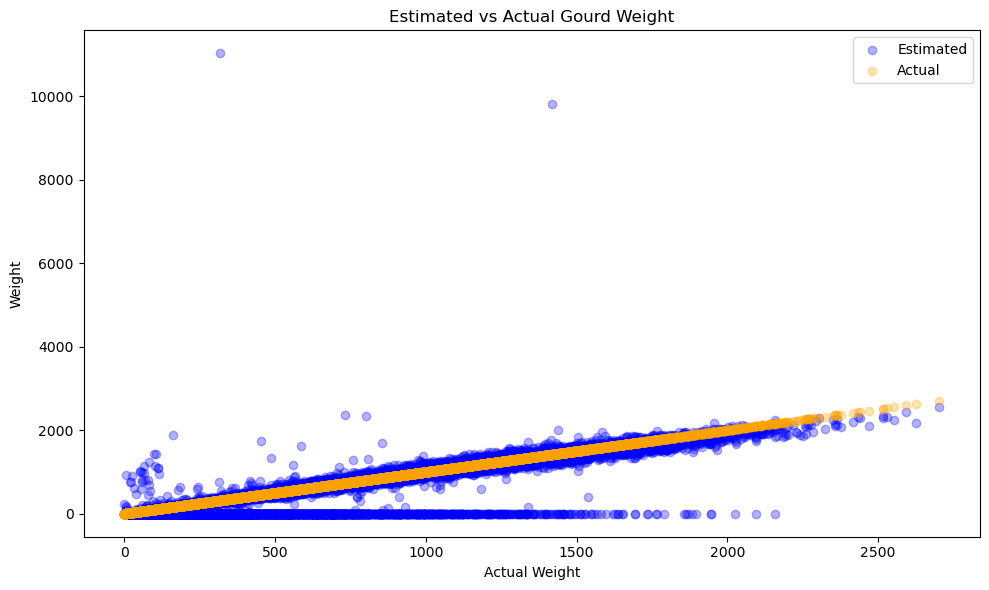

In [17]:
#Scatterplot visual to show relationship between weights

plt.figure(figsize=(10, 6))

plt.scatter(gourds['weight'], gourds['est_weight'], 
            alpha=0.3, label='Estimated', color='blue')
plt.scatter(gourds['weight'], gourds['weight'], 
            alpha=0.3, label='Actual', color='orange')

plt.title('Estimated vs Actual Gourd Weight')
plt.xlabel('Actual Weight')
plt.ylabel('Weight')
plt.legend()
plt.tight_layout()
plt.show()

##### Most of the estimates tend to cluster tightly, which suggests that most guesses are in the ballpark of actual weight. You can see the clear path of the zero line where the cutoff of below-zero estimates begins. Overall, there is a strong positive relationship. The weight is on an upward trend, and the estimated weight continues along that same path.

#### 9. Some growers compete across multiple types of gourd. Which grower has **top 10** finishes across the largest number of types of gourds? What is this grower's best finish that shows up in the dataset?


In [18]:
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin,-25.5
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin,4.5
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin,-30.0
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin,10.2
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin,-139.0


In [19]:
# Filter to top 10 Gourds

top10 = gourds[gourds['place']<= 10]

grower_types = top10.groupby('grower_name')['type_name'].nunique().sort_values(ascending=False)
grower_types.head()

grower_name
Martin, Margaret & Glen    4
Tobeck, Cindy              3
Ansems, Fred               3
Jutras, Joe                3
Werner, Quinn              3
Name: type_name, dtype: int64

In [20]:
# Margaret & Glen's best finish

gourds[gourds['grower_name'] == 'Martin, Margaret & Glen']['place'].min()

2.0

#### 10. The `seed_mother` and `pollinator_father` give information on the parents for each gourd.  
#### 10a. How many gourds appear in the `seed_mother` column at least 100 times?  

In [21]:
# Number of seed_mothers appearing over 100x
seed_count = gourds['seed_mother'].value_counts()
(seed_count >= 100).sum()

np.int64(4)

#### 10b. How many gourds appear in the `pollinator_father` column at least 100 times?  

In [22]:
# Number of pollinator_fathers appearing over 100x
pollinator_count = gourds['pollinator_father'].value_counts()
(pollinator_count >= 100).sum()

np.int64(8)

#### c. How many gourds have at least 100 offspring that have appeared in the GPC Weighoff? That is, how many gourds appear at least 100 times between the `seed_mother` and `pollinator_father` columns combined? Hint: One way you could do this is to create two `value_counts` Series on the `seed_mother` and `pollinator_father` columns and merge them.

In [23]:
# Merge counts together
combined_counts = pd.merge(seed_count, pollinator_count, left_index=True, right_index=True, how='outer').fillna(0)

In [24]:
# Add columns together
combined_counts['total'] = combined_counts['count_x'] + combined_counts['count_y']
(combined_counts['total']>=100).sum()

np.int64(11)

Answers:
    10a. 4 gourds in seed_mother
    10b. 8 gourds in pollinator_father
    10c. 11 gourds combined